In [1]:
# DO NOT CONTAINERISE
# Cell containerization can't parse "!", comment this sign
# =====
# For debug
# ! pip list

# Analysis
# -----
# !pip install python-dotenv
# !pip install scikit-learn
# !pip install tensorflow
# !pip install keras


Package                   Version
------------------------- -----------
absl-py                   2.4.0
affine                    2.4.0
aiohappyeyeballs          2.6.2
aiohttp                   3.14.1
aiosignal                 1.4.0
annotated-types           0.7.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
argopy                    1.3.1
asttokens                 3.0.1
astunparse                1.6.3
attrs                     26.1.0
bokeh                     3.9.1
branca                    0.8.2
Brotli                    1.1.0
cached-property           1.5.2
Cartopy                   0.25.0
certifi                   2026.5.20
cffi                      2.0.0
cftime                    1.6.5
charset-normalizer        3.4.7
click                     8.4.1
click-plugins             1.1.1.2
cligj                     0.7.2
cloudpickle               3.1.2
comm                      0.2.3
contextily                1.7.0
contourpy                 1.3.3
cycler               

In [2]:
# DO NOT CONTAINERISE
# =====
# from Meta learning, to Actual model experiment
# 1st, backbone ml model trained on metalearning datasets, weather data
# 2ed, prediction ml model trained on support datasets, pathogen [病原] data (AnaEE's BioMA platform)

# Botrite (known scientifically as Botrytis cinerea [灰葡萄孢菌]) is 
# a necrotrophic fungal pathogen that causes grey mold, 
# a destructive plant disease affecting over 200 crops, 
# including grapes, tomatoes, strawberries, and ornamentals.

# Dependency
# -----
# ! pip install -r requirements.txt
# ! pip list
# ! conda list

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
import keras
from keras import layers, Model


# base settings
# -----
conf_vlab_name = "ECVs"

param_workflow_name = "workflow name"

# dev
# -----
# conf_dir_workspace = os.path.join("/", "home", "jovyan")

# conf_minio_public_bucket      = "example"
# conf_minio_public_bucket_root = ""
# conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
# conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
# conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

# conf_minio_user_bucket        = "example"
# conf_minio_user_bucket_root   = ""
# conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
# conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
# conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
# conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# local
# -----
conf_dir_data_local_tmp = os.path.join("/", "tmp", "data")

# MINIO
# -----
conf_dir_workspace = os.path.join("/", "home", "jovyan", "Cloud Storage")

conf_minio_public_bucket      = "naa-vre-public"
conf_minio_public_bucket_root = f"vl-{conf_vlab_name.lower()}"
conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

conf_minio_user_bucket        = "naa-vre-user-data"
conf_minio_user_bucket_root   = conf_vlab_name
conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# API key
# -----
# If running under NaaVRE, input `your api key` with the correct value and input in the GUI:
secret_SERVICE_KEY = ""
# secret_SERVICE_KEY = SecretsProvider().set_secret("secret_SERVICE_KEY")
# secret_SERVICE_KEY = SecretsProvider().get_secret("secret_SERVICE_KEY")

# Input param
# -----
conf_delimiter_tsv = "\t"
conf_delimiter_csv = ","

conf_SERVICE_URL_BEACON_NODE_ACTRIS = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_ARGO   = "https://beacon-argo.maris.nl"     # jwt_token=BEACON_TOKEN
conf_SERVICE_URL_BEACON_NODE_CDI    = "https://beacon-cdi.maris.nl"      # jwt_token=BEACON_TOKEN
conf_SERVICE_URL_BEACON_NODE_IAGOS  = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_ICOS   = "https://beacon-iriscc.maris.nl"
conf_SERVICE_URL_BEACON_NODE_IRISCC = "https://beacon-iriscc.maris.nl"

# The ML predicts where a Botritis outbreak is likely to happen
param_fname_metatraining_csv = 'input-metatraining.csv'                  # training dataset, weather
param_fname_observations_csv = 'input-observations.csv'                  # crop disease observations courtesy from AnaEE's BioMA platform
param_fname_weather_csv      = 'input-weather.csv'

param_fname_keras_model      = "output-metamodel.keras"

param_is_train_model        = 1                                          # 1: yes, 0: no

param_data_column_groupby   = "PartitionKey"                             # location
param_data_column_timestamp = 'RowKey'                                   # datatime
param_data_column_target    = 'Botrite'
param_data_column_train     = [
    'LW',          # 
    'RH',          # relative humidity
    'Rain',        # 
    'Temperature'  # 
]
# extra_features = ["cos_doy", "sin_doy"]
# column_train_new = column_train + extra_features

param_data_resample_freq  = "60Min"
param_data_resample_steps = 240                                          # resample with a hourly step, 240 steps are 10 days
param_data_response_len   = 24                                           # predict the next 24 hours
# for _, df_tmp in df_meta.groupby(column_groupby):
#     for x, y in build_data_points(df, data_resample_steps, data_response_len, column_train_new, column_train):
#         X_train.append(x)
#         Y_train.append(y)

param_ml_seed_value = 42
param_ml_batch_size = 16
param_ml_epochs     = 12
# param_ml_batch_size = 1
# param_ml_epochs     = 1

print("Finish: NaaVRE parameters")
print(f"Workspace public:")
print(f"  Root: {conf_minio_public_local_root}")
print(f"  Code: {conf_minio_public_local_code}")
print(f"  Data: {conf_minio_public_local_data}")

print(f"Workspace user:")
print(f"  Root: {conf_minio_user_local_root}")
print(f"  Code: {conf_minio_user_local_code}")
print(f"  Data: {conf_minio_user_local_data}")
print(f"  Log:  {conf_minio_user_local_flog}")


2026-08-05 10:04:38.647176: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 10:04:38.670531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Finish: NaaVRE parameters
Workspace public:
  Root: /home/jovyan/example/
  Code: /home/jovyan/example/code
  Data: /home/jovyan/example/data
Workspace user:
  Root: /home/jovyan/example/
  Code: /home/jovyan/example/library
  Data: /home/jovyan/example/workflow name
  Log:  /home/jovyan/example/workflow name/log.md


In [3]:
# DO NOT CONTAINERISE
# =====
# Link
fname_metatraining_csv = param_fname_metatraining_csv
fname_observations_csv = param_fname_observations_csv
fname_weather_csv      = param_fname_weather_csv


In [ ]:
# ECVs, Get Botrytis Data
# ---
# NaaVRE:
#  cell:
#   outputs:
#    - fname_metatraining: String
#    - fname_observations: String
#    - fname_weather:      String
# ...

import os
import sys
from datetime import datetime

# prepare folders
# -----
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Get Botrytis Data"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("param_fname_metatraining_csv", param_fname_metatraining_csv)  # training datasets
print("param_fname_observations_csv", param_fname_observations_csv)  # crop disease observations courtesy from AnaEE's BioMA platform
print("param_fname_weather_csv",      param_fname_weather_csv)       # training datasets

# output
# -----
fname_metatraining = ""
fname_observations = ""
fname_weather      = ""


# func
# -----

# start
# -----
fname_metatraining = param_fname_metatraining_csv
fname_observations = param_fname_observations_csv
fname_weather      = param_fname_weather_csv

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {fname_metatraining}\n")
    fp_log.write(f"\nOutput: {fname_observations}\n")
    fp_log.write(f"\nOutput: {fname_weather}\n")

print(f"Finish: {workflow_step}")


In [4]:
# ECVs, ML Start
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - fname_metatraining: String
#    - fname_observations: String
#    - fname_weather:      String
#   outputs:
#    - seed_value:          Integer
#    - column_groupby:      String
#    - column_timestamp:    String
#    - column_target:       String
#    - column_train:        List
#    - data_resample_freq:  String
#    - data_resample_steps: Integer
#    - data_response_len:   Integer
# 
#    - file_metatraining: String
#    - file_observations: String
#    - file_weather:      String
# ...

import os
import sys
from datetime import datetime

# prepare folders
# -----
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Start"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("fname_metatraining", fname_metatraining)
print("fname_observations", fname_observations)  
print("fname_weather",      fname_weather)

# output
# -----
print("seed_value",          param_ml_seed_value)

print("column_groupby",      param_data_column_groupby)
print("column_timestamp",    param_data_column_timestamp)
print("column_target",       param_data_column_target)
print("column_train",        param_data_column_train)

print("data_resample_freq",  param_data_resample_freq)
print("data_resample_steps", param_data_resample_steps)
print("data_response_len",   param_data_response_len)

seed_value          = param_ml_seed_value

column_groupby      = param_data_column_groupby
column_timestamp    = param_data_column_timestamp
column_target       = param_data_column_target
column_train        = param_data_column_train

data_resample_freq  = str(param_data_resample_freq)
data_resample_steps = int(param_data_resample_steps)
data_response_len   = int(param_data_response_len)

# func
# -----

# start
# -----
file_metatraining = os.path.join(conf_minio_user_local_data, fname_metatraining)
file_observations = os.path.join(conf_minio_user_local_data, fname_observations)
file_weather      = os.path.join(conf_minio_user_local_data, fname_weather)

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_metatraining}\n")
    fp_log.write(f"\nOutput: {file_observations}\n")
    fp_log.write(f"\nOutput: {file_weather}\n")

print(f"Finish: {workflow_step}")


workflow name
fname_metatraining_csv input-metatraining.csv
fname_observations_csv input-observations.csv
fname_weather_csv input-weather.csv
seed_value 42
column_groupby PartitionKey
column_timestamp RowKey
column_target Botrite
column_train ['LW', 'RH', 'Rain', 'Temperature']
data_resample_freq 60Min
data_resample_steps 240
data_response_len 24
Finish: ECVs-Start


workflow name
seed_value 42
column_groupby PartitionKey
column_timestamp RowKey
column_target Botrite
column_train ['LW', 'RH', 'Rain', 'Temperature']
data_resample_freq 60Min
data_resample_steps 240
data_response_len 24
	 resampling data
	 resampling data
	 resampling data


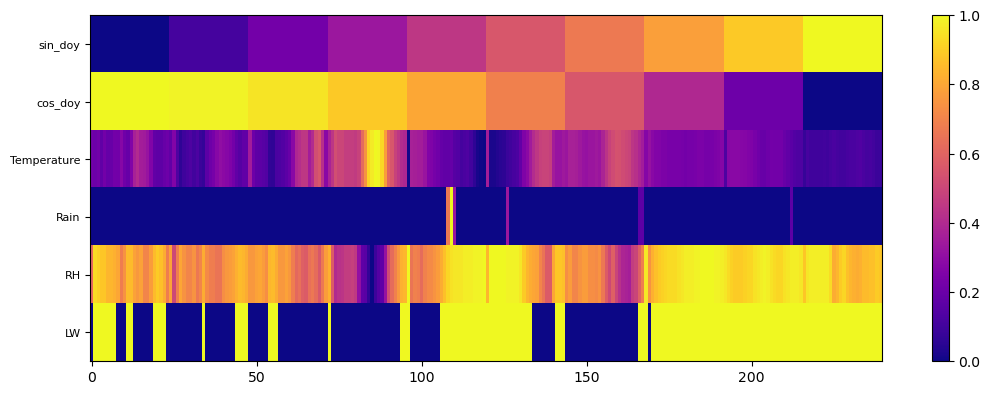

<Figure size 640x480 with 0 Axes>

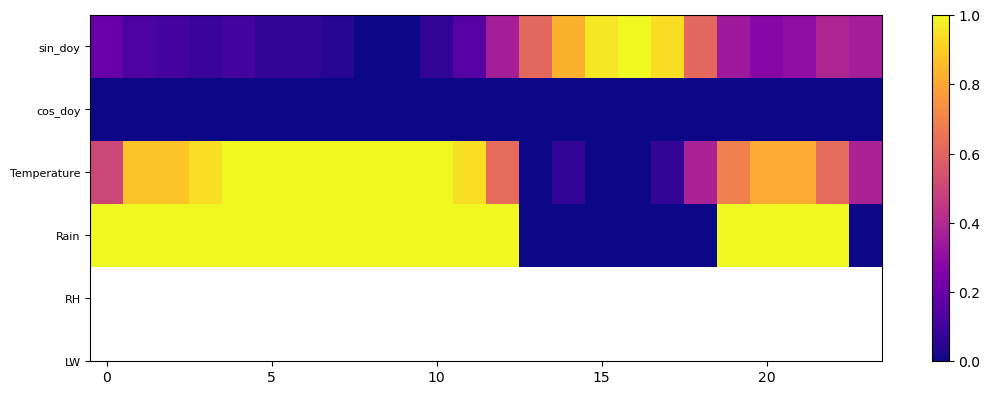

Finish: ECVs-Build training dataset weather


<Figure size 640x480 with 0 Axes>

In [5]:
# ECVs, ML training dataset, weather
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - seed_value:          Integer
#    - column_groupby:      String
#    - column_timestamp:    String
#    - column_target:       String
#    - column_train:        List
#    - data_resample_freq:  String
#    - data_resample_steps: Integer
#    - data_response_len:   Integer
# 
#    - file_metatraining: String
#    - file_observations: String
#    - file_weather:      String
#   outputs:
#    - file_training_dataset: String
# ...

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Build training dataset weather"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("seed_value",          seed_value)

print("column_groupby",      column_groupby)
print("column_timestamp",    column_timestamp)
print("column_target",       column_target)
print("column_train",        column_train)

print("data_resample_freq",  data_resample_freq)
print("data_resample_steps", data_resample_steps)
print("data_response_len",   data_response_len)

print("file_metatraining",   file_metatraining)  # training datasets
print("file_observations",   file_observations)  # crop disease observations courtesy from AnaEE's BioMA platform
print("file_weather",        file_weather)

# output
# -----
fname_output_pkl = "temperate-data_weather.pkl"
file_training_dataset = os.path.join(conf_minio_user_local_data, fname_output_pkl)

fname_output_x_fig = "temperate-train_x.jpg"
fname_output_y_fig = "temperate-train_y.jpg"
file_output_x_fig = os.path.join(conf_minio_user_local_data, fname_output_x_fig)
file_output_y_fig = os.path.join(conf_minio_user_local_data, fname_output_y_fig)

# func
# -----
def get_cyclic_doy(date, functions=[np.cos, np.sin])->List[float]:
    '''
    returns the day of the year expressed as a list of cyclic functions.
    By default it evaluates sin and cos of the normalized DOY.
    '''
    max_doy = 366 if calendar.isleap(date.year) else 365
    rdoy = (date.timetuple().tm_yday -1)/max_doy
    return [f(rdoy * 2 * np.pi) for f in functions]

def resample_dataframe(data_df, interesting_columns=[], resample_freq='60Min', timestamp_column='timestamp', **kwargs):
    print('\t resampling data')
    data_df[timestamp_column] = pd.to_datetime(data_df[timestamp_column])
    data_df.set_index(timestamp_column, inplace=True)
    return data_df.resample(resample_freq).ffill()[interesting_columns].dropna()

def eng_weather_data(df, column='RH'):
    '''this performs all the feature engineering we need'''
    extra_features = ["cos_doy", "sin_doy"]

    # scaling relative humidity
    df[column] = df[column]/100

    # evaluating cyclic doy features
    df[extra_features[0]] = [get_cyclic_doy(x, [np.cos])[0] for x in df.index]
    df[extra_features[1]] = [get_cyclic_doy(x, [np.sin])[0] for x in df.index]
    # returning the engineered data frame and the extra features labels
    return df, extra_features

def build_data_points(df, seq_len, response_seq_len, predictor_cols, response_cols, offset=1, **kwargs):
    """Takes a dataframe and cuts it into sequences of given lenghts, plus
    it returns the following elements as a label. It returns a generator object"""
    begin = 0
    end = seq_len
    while (end + offset + response_seq_len) < len(df):
        yield df[begin:end][predictor_cols].to_numpy(), df[end:(end + response_seq_len)][response_cols].to_numpy()
        begin = begin + offset
        end = end + offset

def plot_time_series(x, variables, file_fig):
    plotarr_scaled = []
    #scale the time series of each variable between 0 and 1:
    scaler = MinMaxScaler(feature_range=(0, 1))
    for row in np.rot90(x):                
        X = row
        Xres = X.reshape(-1, 1)
        scaler.fit(Xres)
        Xtrans = scaler.transform(Xres)  
        rescaled = Xtrans.reshape(1, -1)[0]
        plotarr_scaled.append(rescaled)
    plotarr_scaled = np.array(plotarr_scaled)                  
    
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.grid(False)
    plt.imshow(plotarr_scaled, interpolation='none', cmap='plasma', aspect='auto')
    ax.set_yticks(np.arange(0,len(variables)))
    ax.set_yticklabels(variables, rotation=0,  size = 8)     
    plt.tight_layout()
    plt.colorbar() 
    plt.savefig(file_fig)
    plt.show()
    plt.clf()

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

rtn_data = {
    "X_train": None,
    "Y_train": None,
    "df_meta":         None,
    "df_weather":      None,
    "df_observations": None

}

# chech input the data
# .....
df_meta         = pd.read_csv(file_metatraining)
df_observations = pd.read_csv(file_observations)
df_weather      = pd.read_csv(file_weather)

df_meta.head()
df_observations.head()
df_weather.head()

# positives = pd.to_datetime(df_observations.loc[df_observations[column_target] > 0]['column_timestamp'])
# print(f'Number of Botritis observations: {len(positives)}')
# print('Weather data sample:')

# building training data
# .....
X_train = []
Y_train = []
extra_features = ["cos_doy", "sin_doy"]
column_train_new = column_train + extra_features

for _, df_tmp in df_meta.groupby(column_groupby):
    df = resample_dataframe(
        df_tmp,
        interesting_columns=column_train,
        resample_freq=data_resample_freq,
        timestamp_column=column_timestamp
    )
    
    # feature engineering time
    df, extra_features = eng_weather_data(df)
    for x, y in build_data_points(df, data_resample_steps, data_response_len, column_train_new, column_train):
        X_train.append(x)
        Y_train.append(y)
        #print(f'\tadded {len(x)} data points') 

X_train = np.array(X_train)
Y_train = np.array(Y_train)
# print("Debug", "X_train", X_train)
# print("Debug", "Y_train", Y_train)

# plot data
# flip labels becasue apparently heatmap goes from bottom to top
col_labels = column_train + extra_features
plot_time_series(X_train[0], col_labels[::-1], file_output_x_fig)
plot_time_series(Y_train[0], col_labels[::-1], file_output_y_fig)

# save output
# .....
rtn_data["X_train"] =  X_train
rtn_data["Y_train"] =  Y_train
rtn_data["df_meta"]         =  df_meta
rtn_data["df_weather"]      =  df_weather
rtn_data["df_observations"] =  df_observations

# np.save(file_training_dataset, rtn_data)
with open(file_training_dataset, 'wb') as fp_out:
    pickle.dump(rtn_data, fp_out)

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_training_dataset}\n")

print(f"Finish: {workflow_step}")


In [6]:
# DO NOT CONTAINERISE
# =====
# Link
file_input_dataset = file_training_dataset


workflow name
file_input_dataset /home/jovyan/example/workflow name/temperate-data_weather.pkl
seed_value 42
column_groupby PartitionKey
column_timestamp RowKey
column_target Botrite
column_train ['LW', 'RH', 'Rain', 'Temperature']
data_resample_freq 60Min
data_resample_steps 240
data_response_len 24
	 resampling data


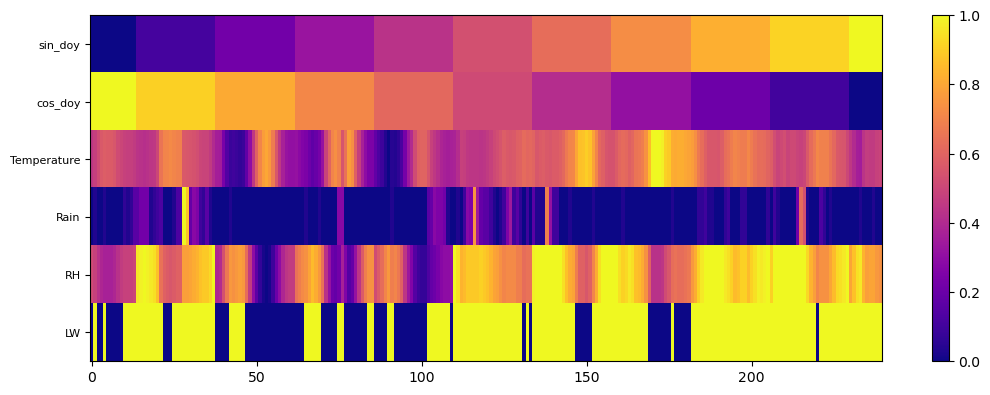

<Figure size 640x480 with 0 Axes>

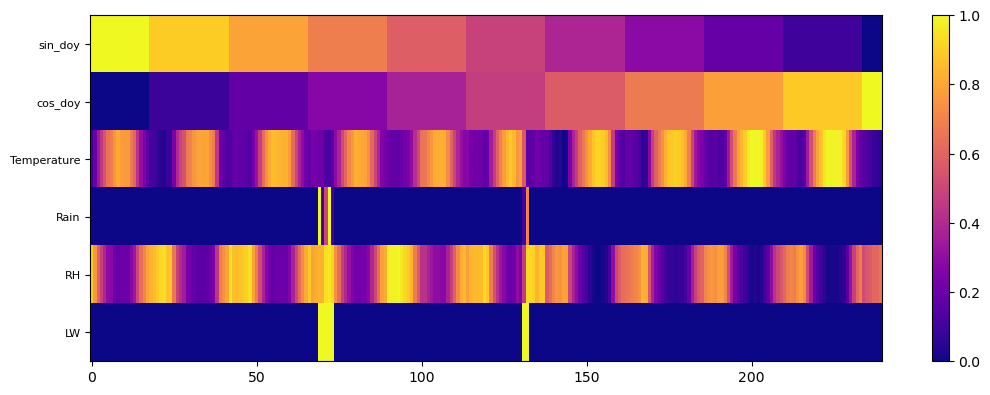

Finish: ECVs-Create support dataset


<Figure size 640x480 with 0 Axes>

In [7]:
# ECVs, ML support dataset, pathogen
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - seed_value:          Integer
#    - column_groupby:      String
#    - column_timestamp:    String
#    - column_target:       String
#    - column_train:        List
#    - data_resample_freq:  String
#    - data_resample_steps: Integer
#    - data_response_len:   Integer
#
#    - file_input_dataset: String
#   outputs:
#    - file_support_dataset: String
# ...

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Create support dataset"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("seed_value",          seed_value)

print("column_groupby",      column_groupby)
print("column_timestamp",    column_timestamp)
print("column_target",       column_target)
print("column_train",        column_train)

print("data_resample_freq",  data_resample_freq)
print("data_resample_steps", data_resample_steps)
print("data_response_len",   data_response_len)

print("file_input_dataset", file_input_dataset)
with open(file_input_dataset, 'rb') as fp_inp:
    inp_data = pickle.load(fp_inp)

# output
# -----
fname_output_pkl      = "temperate-data_weather_pathogen.pkl"
fname_output_x_s1_fig = "temperate-support_x-s1_build.jpg"
fname_output_x_s2_fig = "temperate-support_x-s2_shuffle.jpg"
# fname_output_y_fig = "temperate-support_y.jpg"

file_support_dataset = os.path.join(conf_minio_user_local_data, fname_output_pkl)
file_output_x_s1_fig = os.path.join(conf_minio_user_local_data, fname_output_x_s1_fig)
file_output_x_s2_fig = os.path.join(conf_minio_user_local_data, fname_output_x_s2_fig)
# file_output_y_fig = os.path.join(conf_minio_user_local_data, fname_output_y_fig)

# func
# -----
def resample_dataframe(data_df, interesting_columns=[], resample_freq='60Min', timestamp_column='timestamp', **kwargs):
    print('\t resampling data')
    data_df[timestamp_column] = pd.to_datetime(data_df[timestamp_column])
    data_df.set_index(timestamp_column, inplace=True)
    return data_df.resample(resample_freq).ffill()[interesting_columns].dropna()

def eng_weather_data(df, column='RH'):
    '''this performs all the feature engineering we need'''
    extra_features = ["cos_doy", "sin_doy"]

    # scaling relative humidity
    df[column] = df[column]/100

    # evaluating cyclic doy features
    df[extra_features[0]] = [get_cyclic_doy(x, [np.cos])[0] for x in df.index]
    df[extra_features[1]] = [get_cyclic_doy(x, [np.sin])[0] for x in df.index]
    # returning the engineered data frame and the extra features labels
    return df, extra_features

def build_support_data_points(df, window_size, interesting_columns, point_timestamps):
    for ts in point_timestamps:
        start = pd.to_datetime(ts)+ timedelta(hours=randrange(5,12))
        end = start - timedelta(hours=window_size-1)
        slice_df = df.loc[end:start].copy()[interesting_columns]
        if len(slice_df) == window_size:
            yield slice_df.to_numpy()

# step 1
def build_support_set(
        df_w, df_pat,
        target_column,
        interesting_columns=['LW','RH','Rain','Temperature'],
        timestamp_column='RowKey',
        resample_freq='60Min',
        seq_len=240,
        x=[], y=[]
    ):
    # pathogen presence or lack of thereof
    positives = pd.to_datetime(df_pat.loc[df_pat[target_column] > 0][timestamp_column])
    negatives = pd.to_datetime(df_pat.loc[df_pat[target_column] == 0].sample(n = len(positives))[timestamp_column])
    # weather data preparation
    df_w = resample_dataframe(
        df_w,
        interesting_columns=interesting_columns,
        resample_freq=resample_freq,
        timestamp_column=timestamp_column
    )
    # feature engineering time
    df_w, extra_features = eng_weather_data(df_w)

    # output data structures
    for time_series in build_support_data_points(df_w, window_size=seq_len, interesting_columns=interesting_columns + extra_features, point_timestamps=positives):
        x.append(time_series)
        y.append([1, 0])
    for time_series in build_support_data_points(df_w, window_size=seq_len, interesting_columns=interesting_columns + extra_features, point_timestamps=negatives):
        x.append(time_series)
        y.append([0, 1])
    return x, y

# step 2
def shuffle_data_set(x, y, iterations):
    '''
    Takes the vectorized representation of a data set and shuffles its components 
    to indroduce a hefty amount of randomness
    '''
    assert len(x) == len(y), "Oh no! predictors and response length do not match!"
    last_index = len(x) - 1
    for i in range(iterations):
        a_index = round(random.random() * last_index)
        b_index = round(random.random() * last_index)

        x_value_a = x[a_index]
        y_value_a = y[a_index]

        x[a_index] = x[b_index]
        y[a_index] = y[b_index]

        x[b_index] = x_value_a
        y[b_index] = y_value_a
    return x, y

def plot_time_series(x, variables, file_fig):
    plotarr_scaled = []
    #scale the time series of each variable between 0 and 1:
    scaler = MinMaxScaler(feature_range=(0, 1))
    for row in np.rot90(x):                
        X = row
        Xres = X.reshape(-1, 1)
        scaler.fit(Xres)
        Xtrans = scaler.transform(Xres)  
        rescaled = Xtrans.reshape(1, -1)[0]
        plotarr_scaled.append(rescaled)
    plotarr_scaled = np.array(plotarr_scaled)                  
    
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.grid(False)
    plt.imshow(plotarr_scaled, interpolation='none', cmap='plasma', aspect='auto')
    ax.set_yticks(np.arange(0,len(variables)))
    ax.set_yticklabels(variables, rotation=0,  size = 8)     
    plt.tight_layout()
    plt.colorbar() 
    plt.savefig(file_fig)
    plt.show()
    plt.clf()

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

rtn_data = {
    "X_train":   inp_data["X_train"],
    "Y_train":   inp_data["Y_train"],
    "x_support": None,
    "y_support": None,

    "df_meta":         inp_data["df_meta"],
    "df_weather":      inp_data["df_weather"],
    "df_observations": inp_data["df_observations"],
}

# build support dataset
# .....
x_support = []
y_support = []
extra_features = ["cos_doy", "sin_doy"]

x_support, y_support = build_support_set(
    df_w=inp_data["df_weather"],
    df_pat=inp_data["df_observations"],
    target_column=column_target,
    interesting_columns=column_train,
    resample_freq=data_resample_freq,
    seq_len=data_resample_steps,
    x=x_support,
    y=y_support
)

x_support = np.array(x_support)
y_support = np.array(y_support)
# print("Debug", "x_support, build", x_support)
# print("Debug", "y_support, build", y_support)

# plot data
col_labels = column_train + extra_features
plot_time_series(x_support[0], col_labels[::-1], file_output_x_s1_fig)

# shuffle dataset
# .....
x_support, y_support = shuffle_data_set(x_support, y_support, len(x_support)*2)
# print("Debug", "x_support, shuffle", x_support)
# print("Debug", "y_support, shuffle", y_support)

# plot data
col_labels = column_train + extra_features
plot_time_series(x_support[0], col_labels[::-1], file_output_x_s2_fig)
# plot_time_series(y_support[0], col_labels[::-1], file_output_y_fig)  # ValueError: Axes must be different.

# save output
# .....
rtn_data["x_support"] =  x_support
rtn_data["y_support"] =  y_support

# np.save(file_support_dataset, rtn_data)
with open(file_support_dataset, 'wb') as fp_out:
    pickle.dump(rtn_data, fp_out)

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_support_dataset}\n")

print(f"Finish: {workflow_step}")


In [8]:
# DO NOT CONTAINERISE
# =====
# Link
file_inpput_dataset = file_support_dataset


In [9]:
# ECVs, ML Build Model
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - file_inpput_dataset: String
#
#    - seed_value:          Integer
#    - column_groupby:      String
#    - column_timestamp:    String
#    - column_target:       String
#    - column_train:        List
#    - data_resample_freq:  String
#    - data_resample_steps: Integer
#    - data_response_len:   Integer
#   outputs:
#    - file_model_backbone: String
#    - file_model_meta:     String
#    - file_model_actual:   String
# ...

# meta-learning, weather datasets
# [Seq2Seq](https://www.analyticsvidhya.com/blog/2020/08/a-simple-introduction-to-sequence-to-sequence-models/) architecture,

import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from keras import layers, Model

# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Meta-Learning"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
print("file_inpput_dataset", file_inpput_dataset)
with open(file_inpput_dataset, 'rb') as fp_data:
    inp_data = pickle.load(fp_data)

    X_train = inp_data["X_train"]
    Y_train = inp_data["Y_train"]
    x_support = inp_data["x_support"]
    y_support = inp_data["y_support"]

    x_dims = X_train.shape[-1]
    y_dims = Y_train.shape[-1]
    x_dims_support = x_support.shape[-1]
    y_dims_support = y_support.shape[-1]


print("seed_value",          seed_value)
# print("column_groupby",      column_groupby)
# print("column_timestamp",    column_timestamp)
# print("column_target",       column_target)
# print("column_train",        column_train)
# print("data_resample_freq",  data_resample_freq)
print("data_resample_steps", data_resample_steps)
# print("data_response_len",   data_response_len)

print("is_train_model", param_is_train_model)
is_train_model = True if "1" in str(param_is_train_model) else False

print("batch_size", param_ml_batch_size)
print("epochs",     param_ml_epochs)
batch_size = param_ml_batch_size
epochs     = param_ml_epochs

# output
# -----
fname_model_backbone = f"model-backbone-batch{batch_size}_epoch{epochs}.keras"
file_model_backbone = os.path.join(conf_minio_user_local_data, fname_model_backbone)

fname_model_meta = f"model-meta-batch{batch_size}_epoch{epochs}.keras"
file_model_meta = os.path.join(conf_minio_user_local_data, fname_model_meta)

fname_model_actual = f"model-actual-batch{batch_size}_epoch{epochs}.keras"
file_model_actual = os.path.join(conf_minio_user_local_data, fname_model_actual)

# func
# -----

# start
# -----
# Set seed value
# .....
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

# check GPU
# .....
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print("We got a GPU")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Sorry, no GPU for you...")

# 0. lstm backbone
# .....
model_backbone_input   = layers.Input(shape=(data_resample_steps, x_dims), )
model_backbone_layer_1 = layers.LSTM(64, implementation=1, activation='tanh', return_sequences=True)(model_backbone_input)
model_backbone_layer_2 = layers.LSTM(64, implementation=1, activation='tanh')(model_backbone_layer_1)
model_backbone_output  = layers.Dense(64, activation="relu")(model_backbone_layer_2)

model_backbone = Model(model_backbone_input, model_backbone_output, name='LSTM_backbone')
model_backbone.summary()
with open(conf_minio_user_local_flog, "a+") as f:
    model_backbone.summary(print_fn=lambda x: f.write(x + '\n'))

model_backbone.save(file_model_backbone)

# 1 Meta Model, training the meta-model, weather
# .....
# 1.1. get the number of time-points in the Y tensor
meta_output_steps = int(Y_train.shape[1])

# 1.2. put the backbone in a makeshift model
#  for sequence prediction based on the
#  basically we try to learn to predict the next few items in the sequence
model_meta_input    = layers.Input(shape=(data_resample_steps, x_dims), )
model_meta_backbone = model_backbone(model_meta_input)
model_meta_layer_1  = layers.RepeatVector(meta_output_steps)(model_meta_backbone)
model_meta_layer_2  = layers.LSTM(units=60, activation='tanh', return_sequences=True)(model_meta_layer_1)    # Decoder (second LSTM)
model_meta_output   = layers.TimeDistributed(layers.Dense(y_dims, activation="linear"))(model_meta_layer_2)  # TimeDistributed is to ensure consistency between Dense and Decoder

model_meta = Model(model_meta_input, model_meta_output, name='Meta_Model')
model_meta.summary()
with open(conf_minio_user_local_flog, "a+") as f:
    model_meta.summary(print_fn=lambda x: f.write(x + '\n'))

# 1.3. model.compile
model_meta.compile(optimizer="adam", loss="mean_squared_error")
# keras.utils.plot_model(model_meta, show_shapes=True, rankdir="LR")

# 1.4. model.fit
if is_train_model:
    model_meta.fit(
        X_train,
        Y_train,
        batch_size,
        epochs,

        callbacks=[],
        validation_split=0.1,
        verbose=1,
    )

# 1.5. save output
model_meta.save(file_model_meta)
# del model_meta

# 2. ML Actual Model, training the support, pathogen [病原] data (AnaEE's BioMA platform) 
# .....
# 2.1. split dataset
x_support_train, x_support_test, y_support_train, y_support_test = train_test_split(x_support, y_support, test_size=0.1, random_state=42)

# 2.2. put the backbone in a makeshift model
model_actual_input    = layers.Input(shape=(data_resample_steps, x_dims), )
model_actual_backbone = model_backbone(model_actual_input)
model_actual_layer_1  = layers.Dense(128, activation="relu")(model_actual_backbone)
model_actual_layer_2  = layers.Dense(64,  activation="relu")(model_actual_layer_1)
model_actual_layer_3  = layers.Dropout(0.25)(model_actual_layer_2)
model_actual_output   = layers.Dense(y_dims_support, activation="softmax")(model_actual_layer_3)

model_actual = Model(model_actual_input, model_actual_output, name='Actual_Model')
model_actual.summary()
with open(conf_minio_user_local_flog, "a+") as f:
    model_actual.summary(print_fn=lambda x: f.write(x + '\n'))

# 2.3. model.compile
model_actual.compile(optimizer="adam", loss="categorical_crossentropy")
# keras.utils.plot_model(model_actual, show_shapes=True, rankdir="LR")

# 2.4. model.fit
if is_train_model:
    model_actual.fit(
        x_support_train,
        y_support_train,
        batch_size,
        epochs,

        callbacks=[],
        validation_split=0.1,
        verbose=1,
    )

# 2.5. save output
model_actual.save(file_model_actual)
# del model_actual

# finish
# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_model_backbone}\n")
    fp_log.write(f"\nOutput: {file_model_meta}\n")
    fp_log.write(f"\nOutput: {file_model_actual}\n")

print(f"Finish: {workflow_step}")


workflow name
file_inpput_dataset /home/jovyan/example/workflow name/temperate-data_weather_pathogen.pkl
seed_value 42
data_resample_steps 240
is_train_model 1
batch_size 16
epochs 12
Sorry, no GPU for you...


Model: "LSTM_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 240, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,360 (216.25 KB)

 Trainable params: 55,360 (216.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_backbone (Functional)      │ (None, 64)             │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,066 (281.51 KB)

 Trainable params: 72,066 (281.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - loss: 0.6773 - val_loss: 0.5878
Epoch 2/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - loss: 0.6191 - val_loss: 0.4992
Epoch 3/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - loss: 0.5788 - val_loss: 0.4115
Epoch 4/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - loss: 0.4920 - val_loss: 0.3327
Epoch 5/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - loss: 0.4540 - val_loss: 0.2915
Epoch 6/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - loss: 0.3788 - val_loss: 0.2712
Epoch 7/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - loss: 0.3351 - val_loss: 0.2089
Epoch 8/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - loss: 0.2498 - val_loss: 0.1161
Epoch 9/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - loss: 0.1933 - val_loss: 0.0730
Epoch 10/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - loss: 0.1546 - val_loss: 0.0549
Epoch 11/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - loss: 0.1435 - val_loss: 0.0350
Epoch 12/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - loss: 0.1148 - val_lo

In [10]:
# DO NOT CONTAINERISE
# =====
# Link
file_inpput_dataset = file_support_dataset


workflow name
file_model_backbone /home/jovyan/example/workflow name/model-backbone-batch16_epoch12.keras
file_model_meta /home/jovyan/example/workflow name/model-meta-batch16_epoch12.keras
file_model_actual /home/jovyan/example/workflow name/model-actual-batch16_epoch12.keras
file_inpput_dataset /home/jovyan/example/workflow name/temperate-data_weather_pathogen.pkl
batch_size 16
epochs 12
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step
[[0.1991788  0.         0.         ... 0.         0.         0.31332892]
 [0.20033833 0.         0.         ... 0.         0.         0.3201616 ]
 [0.18693638 0.         0.         ... 0.         0.         0.32339036]
 ...
 [0.2618789  0.         0.         ... 0.         0.         0.21718107]
 [0.30454853 0.01111572 0.         ... 0.         0.         0.13808352]
 [0.05685527 0.         0.         ... 0.         0.         0.        ]]


/tmp/ipykernel_25696/3501793227.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


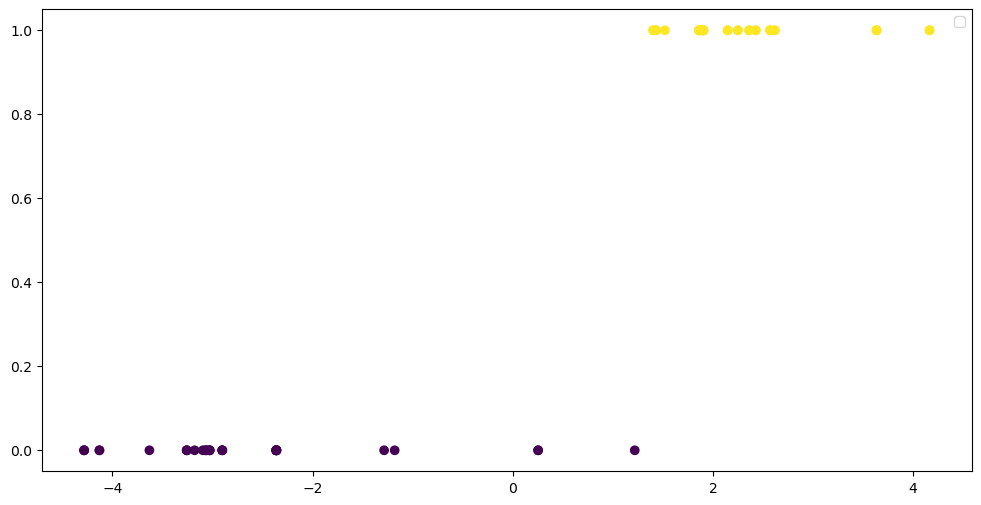

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
pred_meta [[[-3.44100595e-01  5.55285037e-01  3.78028005e-02  1.01629007e+00]
  [-3.77823234e-01  6.89452887e-01 -1.03055090e-02  8.21293116e-01]
  [-5.83617687e-02  7.32645512e-01 -2.93154120e-02  1.10415101e+00]
  [ 6.22869134e-02  6.87084854e-01 -2.29172409e-02  2.13593936e+00]
  [ 2.14781761e-02  6.07670009e-01 -9.41489637e-03  3.72895169e+00]
  [ 4.96888161e-03  5.33506632e-01 -5.18558919e-03  5.65091181e+00]
  [ 1.84149742e-02  4.77892458e-01 -1.52329504e-02  7.59180403e+00]
  [-6.40558004e-02  4.38651592e-01 -3.43803912e-02  9.10921192e+00]
  [-2.59474277e-01  4.14704621e-01 -4.16575819e-02  9.83546066e+00]
  [-9.94050503e-02  4.12302196e-01 -1.71188265e-02  9.69215488e+00]
  [ 1.01843297e-01  4.29448813e-01  2.99317539e-02  8.85747528e+00]
  [ 1.09191120e-01  4.53891486e-01  7.67892227e-02  7.74096441e+00]
  [ 1.73274279e-02  4.78428781e-01  1.11219928e-01  6.62409115e+00]
  [-6.99377060e-02  5.06494045e-01  1.27863929e-01  5.51426220e+00]

<Figure size 640x480 with 0 Axes>

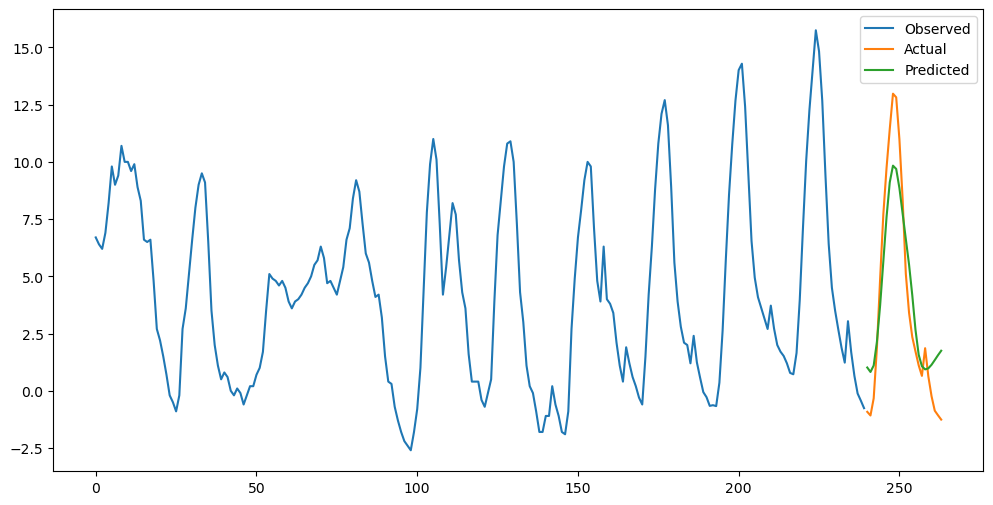

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/stepWARNING:tensorflow:5 out of the last 7 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7898e4e767a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
[[3.3845860e-04 9.9966156e-01]
 [2.6386348e-04 9.9973613e-01]
 [2.3188045e-04 9.9976808e-01]
 [9.4358706e-01 5.6412950e-02]
 [3.3845860e-04 9.9966156e-01]
 [9.5285743e-01 4.7142584e-02]
 [9.4578195e-01

<Figure size 640x480 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

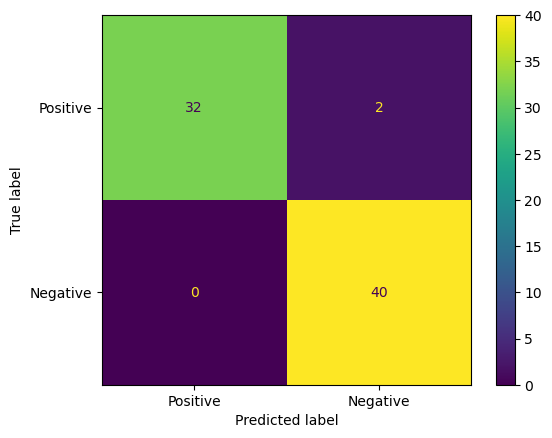

<Figure size 640x480 with 0 Axes>

In [11]:
# ECVs, ML Prediction
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - file_inpput_dataset: String
# 
#    - file_model_backbone: String
#    - file_model_meta:     String
#    - file_model_actual:   String
#   outputs:
#    - file_predict_backbone: String
#    - file_predict_meta:     String
#    - file_predict_actual:   String
# ...

# Pathogen (crop disease observations from AnaEE's BioMA platform)
import os
import sys
from pathlib import Path

from datetime import datetime
from datetime import timedelta

import calendar
from typing import List

import pickle

import random
from random import randrange

import numpy as np
import pandas as pd

import tensorflow as tf
import keras
from keras import layers, Model

# create log
# -----
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-ML Prediction"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
test_idx = -16

print("file_model_backbone", file_model_backbone)
print("file_model_meta",     file_model_meta)
print("file_model_actual",   file_model_actual)
model_backbone = keras.models.load_model(file_model_backbone)
model_meta     = keras.models.load_model(file_model_meta)
model_actual   = keras.models.load_model(file_model_actual)

print("file_inpput_dataset", file_inpput_dataset)
with open(file_inpput_dataset, 'rb') as fp_data:
    inp_data = pickle.load(fp_data)
    
    X_train = inp_data["X_train"]
    Y_train = inp_data["Y_train"]
    x_support = inp_data["x_support"]
    y_support = inp_data["y_support"]

    x_dims = X_train.shape[-1]
    y_dims = Y_train.shape[-1]
    x_dims_support = x_support.shape[-1]
    y_dims_support = y_support.shape[-1]

print("batch_size", param_ml_batch_size)
print("epochs",     param_ml_epochs)
batch_size = param_ml_batch_size
epochs     = param_ml_epochs

# output
# -----
fname_predict_backbone = f"result-predict_backbone-batch{batch_size}_epoch{epochs}.jpg"
file_predict_backbone = os.path.join(conf_minio_user_local_data, fname_predict_backbone)

fname_predict_meta = f"result-predict_meta-batch{batch_size}_epoch{epochs}.jpg"
file_predict_meta = os.path.join(conf_minio_user_local_data, fname_predict_meta)

fname_predict_actual = f"result-predict_actual-batch{batch_size}_epoch{epochs}.jpg"
file_predict_actual = os.path.join(conf_minio_user_local_data, fname_predict_actual)

# func
# -----

# start
# -----
# 0. model_backbone: Vector Space Exploration
# .....
# from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

y_labels = [c[0] for c in y_support]

pred_backbone = model_backbone.predict(x_support)
print(pred_backbone)

# backbone_pca = PCA(n_components=2)
# backbone_pca_fit = backbone_pca.fit_transform(pred_backbone)
# print(backbone_pca_fit.explained_variance_ratio_)

backbone_lda = LinearDiscriminantAnalysis()
backbone_lda_fit = backbone_lda.fit(pred_backbone, y_labels).transform(pred_backbone)

plt.figure(figsize=(12, 6))
# plt.scatter(*zip(*backbone_pca), c=y_labels)
plt.scatter(backbone_lda_fit, y_labels, c=y_labels)
plt.legend()
plt.savefig(file_predict_backbone)
plt.show()
plt.clf()

# 1. model_meta: check model accuracy, temperature
# .....
pred_meta = model_meta.predict(np.array([X_train[test_idx]]))
print("pred_meta", pred_meta)
print("X_train",   X_train)

temp_predict = np.transpose(pred_meta[0])[3]       # Predicted
temp_observe = np.transpose(X_train[test_idx])[3]  # Observed
temp_grdtrue = np.transpose(Y_train[test_idx])[3]  # Actual

plt.figure(figsize=(12, 6))
plt.plot( range(0,                                   len(temp_observe)), temp_observe, label='Observed')
plt.plot( range(len(temp_observe), len(temp_observe)+len(temp_grdtrue)), temp_grdtrue, label='Actual')
plt.plot( range(len(temp_observe), len(temp_observe)+len(temp_predict)), temp_predict, label='Predicted')
plt.legend()
plt.savefig(file_predict_meta)
plt.show()
plt.clf()

# 2. model_actual: check model accuracy, 
# .....
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# pred_actual = model_actual.predict(x_support_test)
pred_actual = model_actual.predict(x_support)
print(pred_actual)

# actual_cm = confusion_matrix(np.transpose(y_support_test)[0], np.transpose(np.round(pred_actual))[0])
actual_cm = confusion_matrix(np.transpose(y_support)[0], np.transpose(np.round(pred_actual))[0])
actual_cm_disp = ConfusionMatrixDisplay(confusion_matrix=actual_cm, display_labels=['Positive', 'Negative'])

plt.figure(figsize=(12, 6))
actual_cm_disp.plot().figure_.savefig(file_predict_actual)
actual_cm_disp.plot()
plt.clf()
